In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
base_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed")

orders = pd.read_csv(
    base_path / "olist_master_order_level.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(
    base_path / "olist_master_item_level.csv"
)

# Sanity checks
orders.head(), items.head()


(                           order_id                       customer_id  \
 0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
 1  00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
 2  000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
 3  00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
 4  00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   
 
   customer_state          customer_city  customer_zip_code_prefix  \
 0             RJ  campos dos goytacazes                     28013   
 1             SP        santa fe do sul                     15775   
 2             MG          para de minas                     35661   
 3             SP                atibaia                     12952   
 4             SP        varzea paulista                     13226   
 
   order_status order_purchase_timestamp order_delivered_customer_date  \
 0    delivered      2017-09-13 08:59:02           2017-09

### Feature Engineering (Shared Logic)

In [3]:
# Delivery flags
orders["is_late"] = orders["delivery_delay_days"] > 0
orders["is_severely_late"] = orders["delivery_delay_days"] > 3
orders["low_review"] = orders["review_score"] <= 2


### Merge Orders ↔ Items (Correct Grain Handling)

- Seller & category analysis must start from item-level, then aggregate.

In [4]:
order_items = items.merge(
    orders[
        [
            "order_id",
            "delivery_delay_days",
            "is_late",
            "is_severely_late",
            "review_score",
            "low_review",
            "total_revenue"
        ]
    ],
    on="order_id",
    how="left"
)


In [9]:
# Standardize column names
order_items = order_items.rename(
    columns={
        "delivery_delay_days_x": "delivery_delay_days",
        "review_score_x": "review_score"
    }
)

# Optional: drop duplicate columns if needed
order_items = order_items.drop(
    columns=[
        "delivery_delay_days_y", 
        "review_score_y"
    ],
    errors="ignore"
)


### Q7  Sellers Contributing Most to Late Deliveries

#### Seller-Level Aggregation

In [10]:
seller_perf = (
    order_items
    .groupby("seller_id")
    .agg(
        order_volume=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
        severe_late_rate=("is_severely_late", "mean"),
        avg_delay=("delivery_delay_days", "mean"),
        revenue=("total_revenue", "sum")
    )
    .query("order_volume >= 50")  # avoid small-sample noise
    .sort_values("late_rate", ascending=False)
)

seller_perf.head(10)


,order_volume,late_rate,severe_late_rate,avg_delay,revenue
seller_id,,,,,
54965bbe3e4f07ae045b90b0b8541f52,78,0.302326,0.290698,-1.814815,15560.58
2a1348e9addc1af5aaa619b1a3679d6b,52,0.272727,0.236364,1.274510,4686.43
6039e27294dc75811c0d8a39069f52c0,64,0.253333,0.120000,-6.500000,27817.50
602044f2c16190c2c6e45eb35c2e21cb,50,0.250000,0.166667,-7.241379,7015.16
beadbee30901a7f61d031b6b686095ad,64,0.235294,0.176471,-9.073529,5943.35
bbad7e518d7af88a0897397ffdca1979,69,0.223529,0.188235,-6.404762,10846.52
a49928bcdf77c55c6d6e05e09a9b4ca5,98,0.216981,0.160377,-3.836538,12521.22
cac4c8e7b1ca6252d8f20b2fc1a2e4af,75,0.216867,0.144578,-4.414634,6963.60
06a2c3af7b3aee5d69171b0e14f0ee87,392,0.211823,0.150246,-10.622829,52511.62


In [8]:
order_items.columns.tolist()


['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'total_payment_value',
 'payment_methods',
 'payment_installments',
 'review_score_x',
 'review_creation_date',
 'delivery_time_days',
 'estimated_delivery_time_days',
 'delivery_delay_days_x',
 'delivery_status',
 'delivery_delay_days_y',
 'is_late',
 'is_severely_late',
 'review_score_y',
 'low_review',
 'total_revenue']

### Visualisation of Worst Late Seller

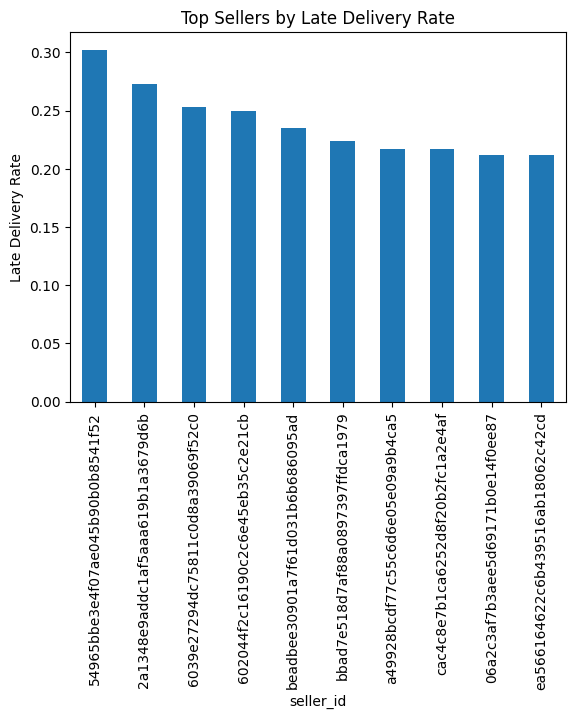

In [11]:
seller_perf.head(10)["late_rate"].plot(
    kind="bar",
    title="Top Sellers by Late Delivery Rate"
)
plt.ylabel("Late Delivery Rate")
plt.show()


### Q8  Sellers Contributing Most to Low Review Scores

In [12]:
seller_reviews = (
    order_items
    .groupby("seller_id")
    .agg(
        avg_review=("review_score", "mean"),
        low_review_rate=("low_review", "mean"),
        review_variance=("review_score", "var"),
        order_volume=("order_id", "nunique")
    )
    .query("order_volume >= 50")
    .sort_values("avg_review")
)

seller_reviews.head(10)


,avg_review,low_review_rate,review_variance,order_volume
seller_id,,,,
1ca7077d890b907f89be8c954a02686a,2.198529,0.649635,2.604739,115
2eb70248d66e0e3ef83659f71b244378,2.716346,0.490566,2.687268,202
602044f2c16190c2c6e45eb35c2e21cb,2.932203,0.483333,3.029807,50
a49928bcdf77c55c6d6e05e09a9b4ca5,2.933333,0.433962,2.793590,98
54965bbe3e4f07ae045b90b0b8541f52,2.938272,0.430233,3.258642,78
972d0f9cf61b499a4812cf0bfa3ad3c4,2.964286,0.420455,2.878227,83
8e6d7754bc7e0f22c96d255ebda59eba,2.968992,0.450382,3.124031,85
2a1348e9addc1af5aaa619b1a3679d6b,3.000000,0.400000,3.056604,52
bbad7e518d7af88a0897397ffdca1979,3.035714,0.447059,3.311962,69


### Delay vs Review (Seller Accountability)

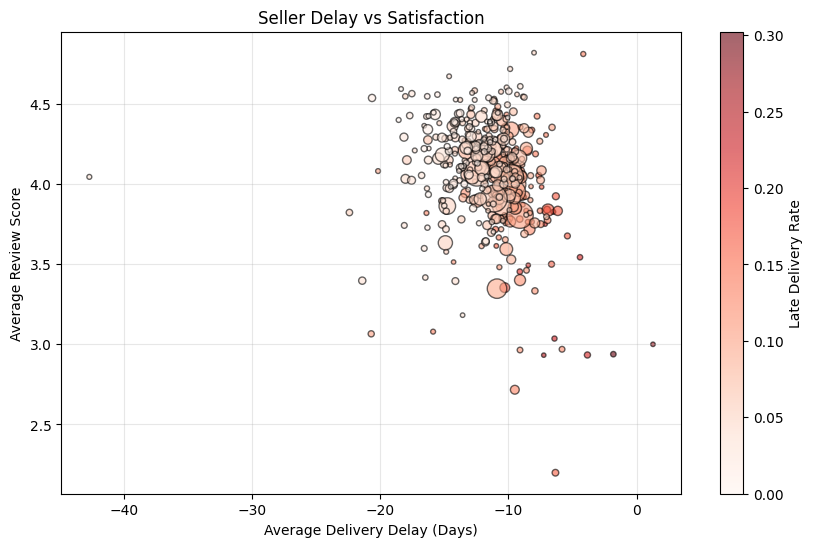

In [14]:
import matplotlib.pyplot as plt

# --- Merge seller_perf and seller_reviews safely ---
# Add suffixes to handle overlapping columns
merged_seller = seller_perf.join(
    seller_reviews,
    how="inner",
    lsuffix="_perf",
    rsuffix="_rev"
)

# --- Scatter plot: Delivery delay vs Avg review ---
plt.figure(figsize=(10,6))
plt.scatter(
    merged_seller["avg_delay"],
    merged_seller["avg_review"],
    s=merged_seller["order_volume_perf"] / 5,  # bubble size proportional to seller order volume
    alpha=0.6,
    c=merged_seller["late_rate"],              # optional: color by late delivery rate
    cmap="Reds",                               # red = more late deliveries
    edgecolor="k"
)
plt.colorbar(label="Late Delivery Rate")       # show color legend
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Average Review Score")
plt.title("Seller Delay vs Satisfaction")
plt.grid(alpha=0.3)
plt.show()


Key Pattern:
 Delay inconsistency hurts more than delay magnitude

### Q11 Top Categories by Revenue vs Satisfaction

#### Category-Level Aggregation

In [16]:
category_perf = (
    order_items
    .groupby("product_category_name")
    .agg(
        order_volume=("order_id", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_review=("review_score", "mean"),
        late_rate=("is_late", "mean"),
        avg_delay=("delivery_delay_days", "mean")
    )
    .query("order_volume >= 100")
)


#### Revenue vs Satisfaction Matrix

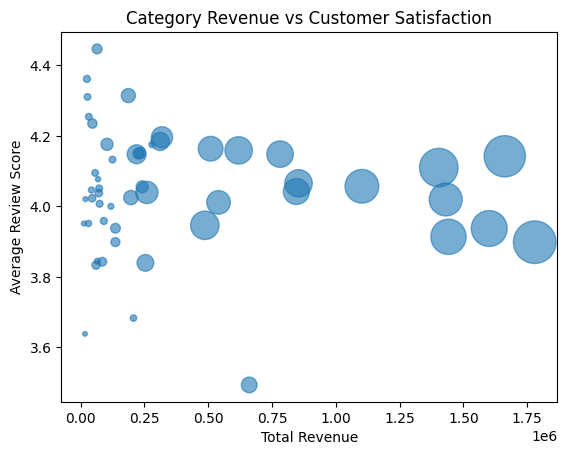

In [17]:
plt.scatter(
    category_perf["revenue"],
    category_perf["avg_review"],
    s=category_perf["order_volume"] / 10,
    alpha=0.6
)
plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")
plt.title("Category Revenue vs Customer Satisfaction")
plt.show()


 DOESNT MAKE SENSE, EDIT IT MORE

### +1 Seller Risk Index (Composite)

In [20]:
# --- Step 1: Check column names in merged_seller ---
print(merged_seller.columns)

# Make sure we know the correct column names:
# - late_rate
# - avg_review
# - order_volume (might have suffix if merged)

# Step 2: Adjust column name if needed
# If you joined seller_perf and seller_reviews, likely order_volume became order_volume_perf
# Replace 'order_volume' with the correct name below
volume_col = "order_volume" if "order_volume" in merged_seller.columns else "order_volume_perf"

# --- Step 3: Compute Seller Risk Index (composite) ---
merged_seller["seller_risk_index"] = (
    merged_seller["late_rate"]
    * (1 / merged_seller["avg_review"])
    * np.log1p(merged_seller[volume_col])
)

# --- Step 4: Rank and show top 10 sellers ---
top_10_sellers = merged_seller.sort_values("seller_risk_index", ascending=False).head(10)
top_10_sellers[["late_rate", "avg_review", volume_col, "seller_risk_index"]]


Index(['order_volume_perf', 'late_rate', 'severe_late_rate', 'avg_delay',
       'revenue', 'avg_review', 'low_review_rate', 'review_variance',
       'order_volume_rev', 'seller_risk_index'],
      dtype='object')


,late_rate,avg_review,order_volume_perf,seller_risk_index
seller_id,,,,
54965bbe3e4f07ae045b90b0b8541f52,0.302326,2.938272,78,0.449583
2a1348e9addc1af5aaa619b1a3679d6b,0.272727,3.000000,52,0.360936
1ca7077d890b907f89be8c954a02686a,0.160584,2.198529,115,0.347209
a49928bcdf77c55c6d6e05e09a9b4ca5,0.216981,2.933333,98,0.339905
602044f2c16190c2c6e45eb35c2e21cb,0.250000,2.932203,50,0.335228
06a2c3af7b3aee5d69171b0e14f0ee87,0.211823,4.002506,392,0.316149
bbad7e518d7af88a0897397ffdca1979,0.223529,3.035714,69,0.312830
88460e8ebdecbfecb5f9601833981930,0.183007,3.353333,248,0.301112
6039e27294dc75811c0d8a39069f52c0,0.253333,3.826667,64,0.276353


Identifies high-impact bad actors, not just noisy ones.

### +2 Category Revenue-at-Risk

In [21]:
category_perf["revenue_at_risk"] = (
    category_perf["revenue"]
    * category_perf["late_rate"]
    * (1 / category_perf["avg_review"])
)

category_perf.sort_values("revenue_at_risk", ascending=False).head(10)


,order_volume,revenue,avg_review,late_rate,avg_delay,revenue_at_risk
product_category_name,,,,,,
cama_mesa_banho,9417,1779073.46,3.898393,0.078379,-11.070743,35769.031299
beleza_saude,8836,1661799.70,4.141946,0.083419,-11.368765,33468.874733
informatica_acessorios,6689,1600843.12,3.937226,0.072065,-11.793063,29301.101976
moveis_decoracao,6449,1441206.51,3.913673,0.077236,-11.844689,28441.999442
relogios_presentes,5624,1430422.30,4.019532,0.077039,-11.323043,27415.534554
esporte_lazer,7720,1403288.60,4.109786,0.068536,-11.415681,23401.593597
automotivo,3897,853853.19,4.065202,0.076651,-10.817568,16099.730225
moveis_escritorio,1273,660664.06,3.493739,0.083628,-11.218507,15813.969796
utilidades_domesticas,5884,1102045.79,4.056874,0.056320,-11.718713,15299.234292


- Shows where poor operations threaten core business revenue.

### +3 Satisfaction Elasticity 

In [22]:
elasticity = (
    order_items
    .groupby("product_category_name")
    .apply(lambda x: np.corrcoef(
        x["delivery_delay_days"], x["review_score"]
    )[0,1])
    .rename("delay_review_correlation")
)

category_perf = category_perf.join(elasticity)
category_perf.sort_values("delay_review_correlation").head(10)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18260\255938513.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.corrcoef(


,order_volume,revenue,avg_review,late_rate,avg_delay,revenue_at_risk,delay_review_correlation
product_category_name,,,,,,,
agro_industria_e_comercio,182,118725.45,4.000000,0.037736,-10.820388,1120.051415,NaN
alimentos,450,46411.27,4.234694,0.084314,-9.264529,924.059021,NaN
alimentos_bebidas,227,27289.76,4.310219,0.050360,-10.970260,318.847944,NaN
artes,202,30992.93,3.951456,0.066986,-12.208122,525.396530,NaN
artigos_de_natal,128,18994.93,4.020548,0.117647,-11.426667,555.819176,NaN
audio,350,60324.62,3.833333,0.120879,-9.533149,1902.257487,NaN
automotivo,3897,853853.19,4.065202,0.076651,-10.817568,16099.730225,NaN
bebes,2885,540307.17,4.011203,0.080183,-11.033501,10800.550219,NaN
bebidas,297,71397.18,4.037534,0.050132,-10.853186,886.501163,NaN


- Justifies category-specific SLA policies.

#### Final Tables Export

In [23]:
merged_seller.to_csv("seller_risk_table.csv")
category_perf.to_csv("category_risk_table.csv")
